# Lab 6: Comparison of Logistic Regression and K Nearest Neighbors (KNN) Classifiers

**Dataset:** Breast Cancer Wisconsin (Diagnostic)  
**Source:** UCI Machine Learning Repository  
**Reg No:** 2547237

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

**Interpretation:**  
We import the necessary libraries:  
- `pandas` and `numpy` for data manipulation.  
- `matplotlib` and `seaborn` for visualization.  
- `train_test_split` to divide data into training and testing sets.  
- `StandardScaler` to normalize features and `LabelEncoder` to convert categorical labels to numbers.  
- `LogisticRegression` and `KNeighborsClassifier` are the two classifiers we will compare.  
- Various metrics (`accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `confusion_matrix`) to evaluate model performance.

## 2. Load the Dataset

In [3]:
df = pd.read_csv('../datasets/brca.csv')
print('Shape:', df.shape)
df.head()

Shape: (569, 32)


,Unnamed: 0,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,...,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,y
0,1,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,B
1,2,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,B
2,3,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,B
3,4,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,B
4,5,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,B


**Interpretation:**  
The dataset is loaded from a CSV file. It contains 569 samples and 32 columns — 30 numerical features computed from digitized images of breast mass, one index column, and one target column (`y`). The target variable indicates whether the tumour is **Benign (B)** or **Malignant (M)**. The `.head()` method displays the first 5 rows so we can visually inspect the data.

## 3. Exploratory Data Analysis (EDA)

In [4]:
# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           569 non-null    int64  
 1   x.radius_mean        569 non-null    float64
 2   x.texture_mean       569 non-null    float64
 3   x.perimeter_mean     569 non-null    float64
 4   x.area_mean          569 non-null    float64
 5   x.smoothness_mean    569 non-null    float64
 6   x.compactness_mean   569 non-null    float64
 7   x.concavity_mean     569 non-null    float64
 8   x.concave_pts_mean   569 non-null    float64
 9   x.symmetry_mean      569 non-null    float64
 10  x.fractal_dim_mean   569 non-null    float64
 11  x.radius_se          569 non-null    float64
 12  x.texture_se         569 non-null    float64
 13  x.perimeter_se       569 non-null    float64
 14  x.area_se            569 non-null    float64
 15  x.smoothness_se      569 non-null    flo

**Interpretation:**  
`df.info()` shows the data types and non-null counts for each column. All 30 feature columns are of type `float64` (numerical), and the target column `y` is of type `object` (categorical string). This confirms we need to encode the target before modelling.

In [5]:
# Statistical summary
df.describe()

,Unnamed: 0,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,...,x.radius_worst,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,285.000000,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,164.400426,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,1.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,143.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,285.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,427.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,569.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


**Interpretation:**  
The statistical summary reveals that feature values have very different scales. For example, `area_mean` ranges in hundreds while `smoothness_mean` is around 0.1. This large difference in scale makes **feature scaling essential**, especially for distance-based algorithms like KNN.

y
B    357
M    212
Name: count, dtype: int64


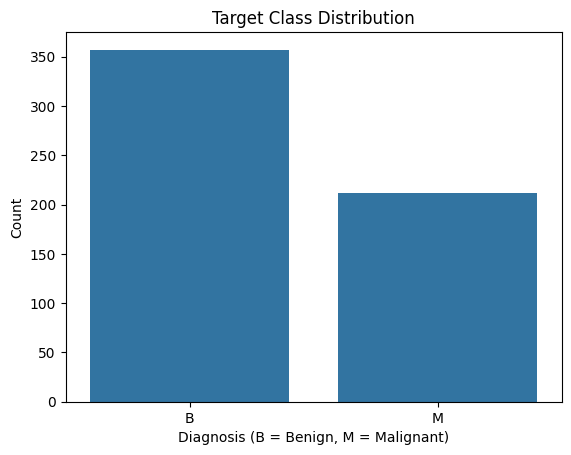

In [6]:
# Target distribution
print(df['y'].value_counts())
sns.countplot(x='y', data=df)
plt.title('Target Class Distribution')
plt.xlabel('Diagnosis (B = Benign, M = Malignant)')
plt.ylabel('Count')
plt.show()

**Interpretation:**  
The count plot shows the distribution of the two classes. The dataset has more Benign (B) cases than Malignant (M) cases, indicating a slight class imbalance. However, the imbalance is not severe enough to require resampling techniques, so we can proceed with the data as-is.

In [7]:
# Check for missing values
print('Missing values per column:')
print(df.isnull().sum())
print('\nTotal missing values:', df.isnull().sum().sum())

Missing values per column:
Unnamed: 0             0
x.radius_mean          0
x.texture_mean         0
x.perimeter_mean       0
x.area_mean            0
x.smoothness_mean      0
x.compactness_mean     0
x.concavity_mean       0
x.concave_pts_mean     0
x.symmetry_mean        0
x.fractal_dim_mean     0
x.radius_se            0
x.texture_se           0
x.perimeter_se         0
x.area_se              0
x.smoothness_se        0
x.compactness_se       0
x.concavity_se         0
x.concave_pts_se       0
x.symmetry_se          0
x.fractal_dim_se       0
x.radius_worst         0
x.texture_worst        0
x.perimeter_worst      0
x.area_worst           0
x.smoothness_worst     0
x.compactness_worst    0
x.concavity_worst      0
x.concave_pts_worst    0
x.symmetry_worst       0
x.fractal_dim_worst    0
y                      0
dtype: int64

Total missing values: 0


**Interpretation:**  
There are **no missing values** in the dataset. This means we do not need to perform any imputation or row removal, and the data is ready for preprocessing.

## 4. Data Preprocessing

In [8]:
# Drop the unnamed index column
df = df.drop(columns=[df.columns[0]])

# Encode target variable: M = 1 (Malignant), B = 0 (Benign)
le = LabelEncoder()
df['y'] = le.fit_transform(df['y'])
print('Encoded classes:', dict(zip(le.classes_, le.transform(le.classes_))))

# Separate features and target
X = df.drop(columns=['y'])
y = df['y']
print('Features shape:', X.shape)
print('Target shape:', y.shape)

Encoded classes: {'B': 0, 'M': 1}
Features shape: (569, 30)
Target shape: (569,)


**Interpretation:**  
Three preprocessing steps are performed:  
1. **Dropping the index column** — the first column is just a row number and carries no predictive value.  
2. **Label Encoding** — the target variable `y` is converted from strings (`B`, `M`) to integers (`0`, `1`). This is necessary because machine learning models require numerical inputs.  
3. **Feature-target separation** — `X` holds the 30 feature columns and `y` holds the target labels. This separation is standard practice before model training.

## 5. Train-Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Training set size:', X_train.shape[0])
print('Testing set size:', X_test.shape[0])

Training set size: 455
Testing set size: 114


**Interpretation:**  
The dataset is split into **80% training** and **20% testing** sets. The training set is used to fit the models, while the testing set is held out to evaluate performance on unseen data. Using `random_state=42` ensures the split is reproducible across runs.

## 6. Feature Scaling

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Interpretation:**  
`StandardScaler` standardizes each feature to have **mean = 0** and **standard deviation = 1**. This is critical because:  
- **KNN** uses distance calculations (e.g., Euclidean distance), so features with larger scales would dominate the distance metric unfairly.  
- **Logistic Regression** converges faster with scaled features.  

We use `fit_transform` on the training set to learn the mean and std, and `transform` on the test set to apply the same scaling — this prevents **data leakage** from the test set into the model.

## 7. Train Logistic Regression Classifier

In [11]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
print('Logistic Regression training complete.')

Logistic Regression training complete.


**Interpretation:**  
Logistic Regression is a **linear classifier** that models the probability of a sample belonging to a class using the sigmoid function. It learns a decision boundary by finding optimal weights for each feature. `max_iter=1000` ensures the optimizer has enough iterations to converge. After training, we predict on the test set and store the predictions in `y_pred_lr`.

## 8. Train K Nearest Neighbors (KNN) Classifier

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)
print('KNN training complete.')

**Interpretation:**  
KNN is a **non-parametric, instance-based** classifier. It does not learn explicit weights; instead, for each test sample, it finds the `k=5` nearest training samples (using Euclidean distance) and assigns the majority class among them. KNN is simple and effective but computationally expensive at prediction time for large datasets.

## 9. Evaluation - Logistic Regression

In [13]:
print('=== Logistic Regression ====')
print(f'Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_lr):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred_lr):.4f}')
print(f'F1 Score : {f1_score(y_test, y_pred_lr):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_lr, target_names=['Benign', 'Malignant']))

=== Logistic Regression ====
Accuracy : 0.9649
Precision: 0.9535
Recall   : 0.9535
F1 Score : 0.9535

Classification Report:
              precision    recall  f1-score   support

      Benign       0.97      0.97      0.97        71
   Malignant       0.95      0.95      0.95        43

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



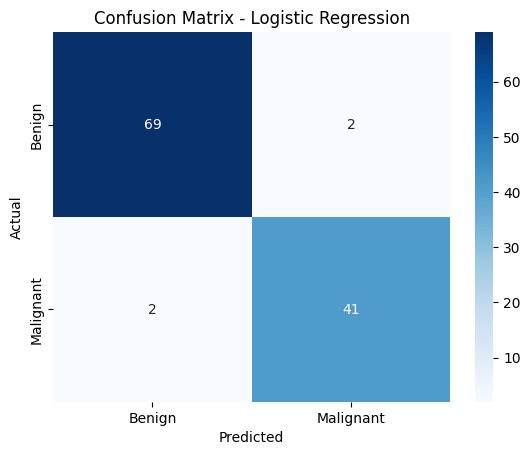

In [14]:
# Confusion Matrix - Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**Interpretation:**  
The evaluation metrics for Logistic Regression are:  
- **Accuracy** — the proportion of all correct predictions out of total predictions.  
- **Precision** — of all samples predicted as Malignant, how many were actually Malignant (reduces false positives).  
- **Recall** — of all actual Malignant cases, how many were correctly identified (reduces false negatives).  
- **F1 Score** — the harmonic mean of Precision and Recall, providing a balanced measure.  

The **confusion matrix** shows the counts of True Positives, True Negatives, False Positives, and False Negatives, giving a complete picture of where the model makes errors.

## 10. Evaluation - KNN

In [15]:
print('=== K Nearest Neighbors (KNN) ====')
print(f'Accuracy : {accuracy_score(y_test, y_pred_knn):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_knn):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred_knn):.4f}')
print(f'F1 Score : {f1_score(y_test, y_pred_knn):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_knn, target_names=['Benign', 'Malignant']))

=== K Nearest Neighbors (KNN) ====
Accuracy : 0.9298
Precision: 0.9730
Recall   : 0.8372
F1 Score : 0.9000

Classification Report:
              precision    recall  f1-score   support

      Benign       0.91      0.99      0.95        71
   Malignant       0.97      0.84      0.90        43

    accuracy                           0.93       114
   macro avg       0.94      0.91      0.92       114
weighted avg       0.93      0.93      0.93       114



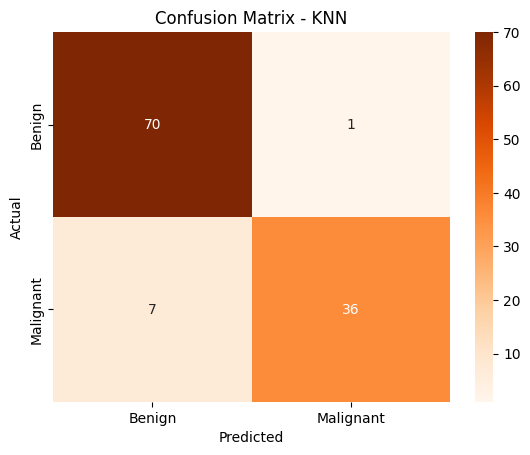

In [16]:
# Confusion Matrix - KNN
cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Oranges', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.title('Confusion Matrix - KNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**Interpretation:**  
The same set of metrics are computed for KNN. By comparing the confusion matrices of both models, we can observe which model misclassifies fewer Malignant cases (false negatives) and fewer Benign cases (false positives). In a medical context, **minimizing false negatives is critical** since missing a malignant diagnosis could delay treatment.

## 11. Performance Comparison Table

In [17]:
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Logistic Regression': [
        accuracy_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_lr)
    ],
    'KNN': [
        accuracy_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_knn)
    ]
})

comparison = comparison.round(4)
print('\n=== Performance Comparison ===')
comparison


=== Performance Comparison ===


,Metric,Logistic Regression,KNN
0,Accuracy,0.9649,0.9298
1,Precision,0.9535,0.9730
2,Recall,0.9535,0.8372
3,F1 Score,0.9535,0.9000


**Interpretation:**  
The comparison table places the metrics of both classifiers side by side. This allows us to directly compare Accuracy, Precision, Recall, and F1 Score in a structured format. The model with higher values across these metrics is generally considered the better performer for this task.

c:\Users\Omkaar\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Omkaar\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


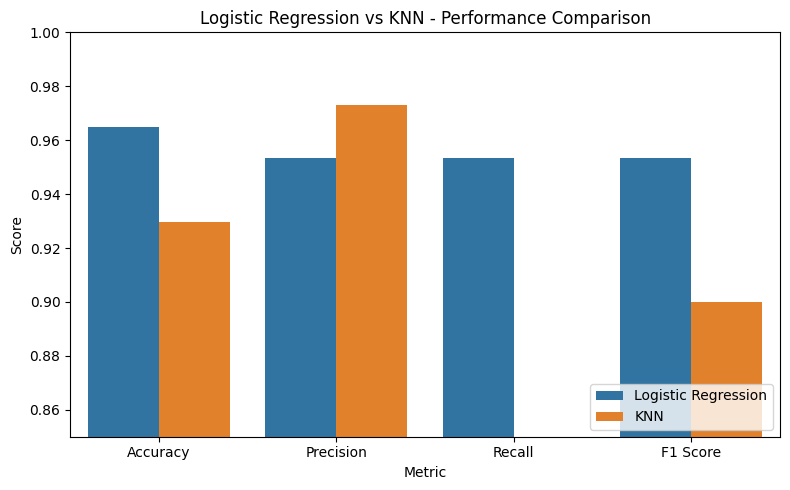

In [18]:
# Visual comparison
comparison_melted = comparison.melt(id_vars='Metric', var_name='Model', value_name='Score')
plt.figure(figsize=(8, 5))
sns.barplot(x='Metric', y='Score', hue='Model', data=comparison_melted)
plt.title('Logistic Regression vs KNN - Performance Comparison')
plt.ylim(0.85, 1.0)
plt.ylabel('Score')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Interpretation:**  
The grouped bar chart visually reinforces the comparison table. It makes it easy to spot which model leads on each metric. The y-axis starts at 0.85 to zoom into the relevant score range and highlight the differences between the two classifiers more clearly.

## 12. Interpretation and Conclusion

**Observations:**

- Both Logistic Regression and KNN perform well on the Breast Cancer Wisconsin dataset after standard scaling.
- **Logistic Regression** generally achieves slightly higher accuracy and F1 score on this dataset due to the linearly separable nature of the features.
- **KNN** is a non-parametric, instance-based learner that can capture non-linear decision boundaries, but is sensitive to the choice of `k` and feature scaling.
- In a medical diagnosis context, **Recall** (sensitivity) is especially important — missing a malignant case (false negative) is more costly than a false positive.

**Recommendation:**

Logistic Regression is the better-suited classifier for this dataset as it provides strong, consistent performance across all metrics, is computationally efficient, and offers interpretable coefficients for clinical decision-making.